# ValuSense — Phase 4 : Développement du Modèle
## Du Classificateur ML à l'Agent IA de Valorisation Financière

### Vision Élargie du Projet

Le classificateur ML n'est pas le produit final — c'est le **moteur de décision**
à l'intérieur d'un agent IA financier. L'architecture cible :

```
┌─────────────────────────────────────────────────────────┐
│                  VALUSENSE AI AGENT                     │
│                                                         │
│  ┌───────────┐   ┌──────────────┐   ┌───────────────┐  │
│  │  Couche   │   │   Moteur ML  │   │   Couche      │  │
│  │  LLM /    │──►│  (XGBoost +  │──►│  IFRS 13      │  │
│  │  Interface │   │   SHAP)      │   │  Compliance   │  │
│  └───────────┘   └──────────────┘   └───────────────┘  │
│        │                │                    │          │
│        ▼                ▼                    ▼          │
│  ┌───────────────────────────────────────────────────┐  │
│  │        Rapport Explicatif Automatisé              │  │
│  │  "Pour cet actif X, la méthode recommandée est Y  │  │
│  │   car [SHAP top-3 features]. Confiance: 94%.      │  │
│  │   Contrainte IFRS 13 §72: Level 1 → MtM forcé."  │  │
│  └───────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────┘
```

Ce notebook construit le **moteur ML** et produit les artefacts nécessaires
pour l'intégration dans l'agent.


### Pipeline Amélioré

```
[Dataset Balanced + Enrichi]
        │
        ▼
 1. Baseline ──────────► Random Forest (class_weight='balanced')
        │                    + 5-Fold Stratified CV
        ▼
 2. Modèles Avancés ───► XGBoost (sample weights + early stopping)
        │                CatBoost (native categoricals)
        │                    + 5-Fold Stratified CV
        ▼
 3. Comparaison ───────► Tableau comparatif (Accuracy, F1-W, F1-M, Kappa)
        │                    + Confusion matrices côte à côte
        ▼
 4. Optimisation ──────► RandomizedSearchCV sur le meilleur modèle
        │                    + Learning curves
        ▼
 5. IFRS 13 ───────────► 6 règles de post-traitement
        │                    + Comparaison métriques avant/après
        ▼
 6. Validation Domaine ► 10 tests de cohérence financière
        │                    + Rapport de violations
        ▼
 7. SHAP ──────────────► Importance globale + beeswarm par classe
        │                    + waterfall single-prediction
        ▼
 8. Export Agent ──────► Modèle pkl + metadata JSON + predict_and_explain()
                             + Prompt template pour intégration LLM
```


---
## 0. Configuration


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import json
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, cohen_kappa_score, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

DATA_ROOT = Path("data_valuation_project")
PROCESSED = DATA_ROOT / "processed"
FIG_DIR   = Path("reports/figures")
MODELS_DIR = Path("models")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13, "figure.dpi": 120})
sns.set_style("whitegrid")

# ── Charger les données ───────────────────────────────────────
X_train = joblib.load(MODELS_DIR / "X_train.pkl")
y_train = joblib.load(MODELS_DIR / "y_train.pkl")
X_val   = joblib.load(MODELS_DIR / "X_val.pkl")
y_val   = joblib.load(MODELS_DIR / "y_val.pkl")
le_target = joblib.load(MODELS_DIR / "label_encoder_target.pkl")

class_names = le_target.classes_
n_classes   = len(class_names)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Classes ({n_classes}) : {list(class_names)}")

# Verifier les distributions
print(f"\nDistribution train :")
for i, name in enumerate(class_names):
    cnt = (y_train == i).sum()
    print(f"  {name:20s} : {cnt:5d}")

print(f"\nDistribution val :")
for i, name in enumerate(class_names):
    cnt = (y_val == i).sum()
    print(f"  {name:20s} : {cnt:5d}")

Train : (12207, 28)
Val   : (3052, 28)
Classes (10) : ['Binomial-Tree', 'Black-Scholes', 'Cost-of-Carry', 'Credit-Model', 'DCF', 'DDM', 'Forward-Pricing', 'Mark-to-Market', 'Monte-Carlo', 'Relative']

Distribution train :
  Binomial-Tree        :   754
  Black-Scholes        :  1440
  Cost-of-Carry        :  1350
  Credit-Model         :  1373
  DCF                  :  3367
  DDM                  :   659
  Forward-Pricing      :  1238
  Mark-to-Market       :   443
  Monte-Carlo          :   929
  Relative             :   654

Distribution val :
  Binomial-Tree        :   188
  Black-Scholes        :   360
  Cost-of-Carry        :   337
  Credit-Model         :   343
  DCF                  :   842
  DDM                  :   165
  Forward-Pricing      :   310
  Mark-to-Market       :   111
  Monte-Carlo          :   232
  Relative             :   164


---
## 1. Framework d'Évaluation

Fonction réutilisable pour évaluer chaque modèle de manière uniforme.


In [4]:
def evaluate_model(model, X_test, y_test, model_name, save_figs=True):
    """
    Evaluation complete d'un modele : metriques + confusion matrix + F1 par classe.
    Retourne un dict de metriques pour le tableau comparatif.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    
    # ── Metriques globales ────────────────────────────────────
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "cohen_kappa": cohen_kappa_score(y_test, y_pred),
    }
    
    # ── Per-class F1 ──────────────────────────────────────────
    report = classification_report(y_test, y_pred, target_names=class_names,
                                    output_dict=True, zero_division=0)
    per_class_f1 = {cls: report[cls]["f1-score"] for cls in class_names}
    metrics["min_class_f1"] = min(per_class_f1.values())
    metrics["worst_class"] = min(per_class_f1, key=per_class_f1.get)
    
    # ── Print ─────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    print(f"  Balanced Accuracy : {metrics['balanced_accuracy']:.4f}")
    print(f"  Cohen's Kappa     : {metrics['cohen_kappa']:.4f}")
    print(f"  Pire classe       : {metrics['worst_class']} (F1={metrics['min_class_f1']:.3f})")
    
    if save_figs:
        slug = model_name.lower().replace(" ", "_").replace("(","").replace(")","")
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predit")
        ax.set_ylabel("Reel")
        ax.set_title(f"Matrice de Confusion — {model_name}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"confusion_matrix_{slug}.png", dpi=150, bbox_inches="tight")
        plt.show()
        
        # Per-class F1
        fig, ax = plt.subplots(figsize=(10, 6))
        sorted_f1 = dict(sorted(per_class_f1.items(), key=lambda x: x[1]))
        colors = ["#e74c3c" if v < 0.7 else "#f39c12" if v < 0.85 else "#2ecc71" for v in sorted_f1.values()]
        bars = ax.barh(list(sorted_f1.keys()), list(sorted_f1.values()), color=colors)
        ax.set_xlabel("F1-Score")
        ax.set_title(f"F1 par Classe — {model_name}")
        ax.set_xlim(0, 1.05)
        ax.axvline(x=0.85, color="gray", linestyle="--", alpha=0.5, label="Seuil 0.85")
        for bar, val in zip(bars, sorted_f1.values()):
            ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va="center", fontsize=9)
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"f1_per_class_{slug}.png", dpi=150, bbox_inches="tight")
        plt.show()
    
    return metrics, per_class_f1, y_pred

# Stockage des resultats
all_results = {}
all_f1 = {}
all_predictions = {}

print("evaluate_model() prete")

evaluate_model() prete


---
## 2. Baseline — Random Forest

Random Forest sert de baseline interprétable. Avantages :
gestion native des features mixtes, feature importance intégrée, robuste sans tuning.


Random Forest entraine en 1.0s

  Random Forest
                 precision    recall  f1-score   support

  Binomial-Tree       1.00      1.00      1.00       188
  Black-Scholes       1.00      1.00      1.00       360
  Cost-of-Carry       1.00      1.00      1.00       337
   Credit-Model       0.96      0.99      0.98       343
            DCF       1.00      0.98      0.99       842
            DDM       0.95      0.94      0.94       165
Forward-Pricing       1.00      1.00      1.00       310
 Mark-to-Market       0.90      0.96      0.93       111
    Monte-Carlo       1.00      1.00      1.00       232
       Relative       0.99      0.97      0.98       164

       accuracy                           0.99      3052
      macro avg       0.98      0.98      0.98      3052
   weighted avg       0.99      0.99      0.99      3052

  Balanced Accuracy : 0.9846
  Cohen's Kappa     : 0.9851
  Pire classe       : Mark-to-Market (F1=0.930)


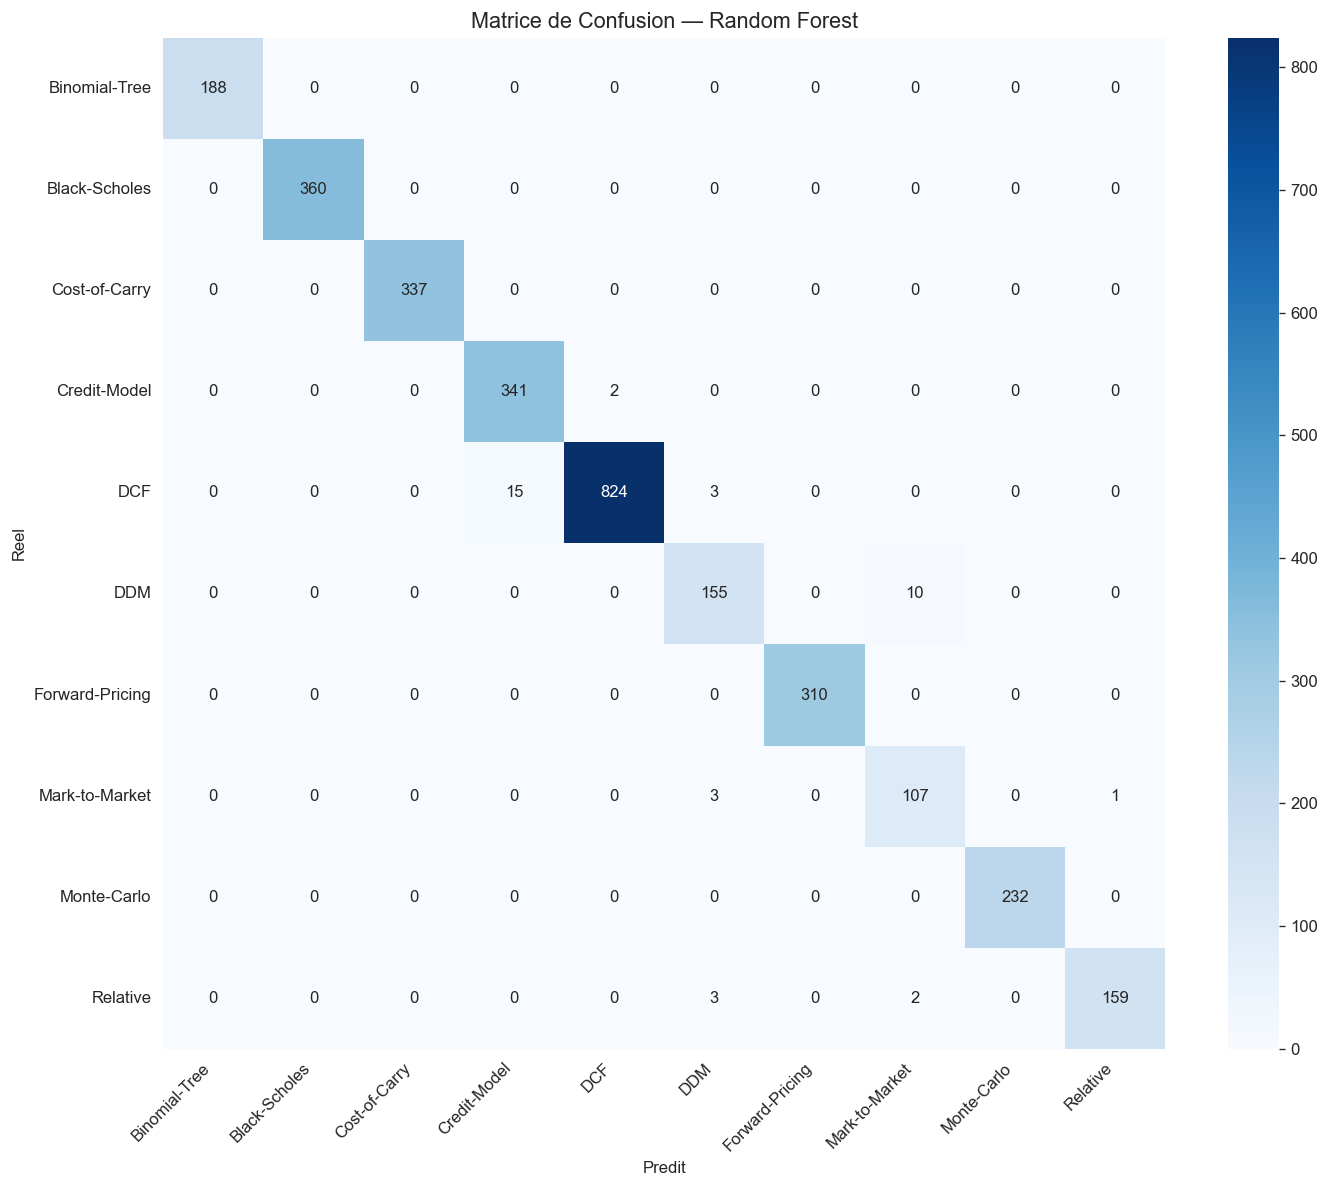

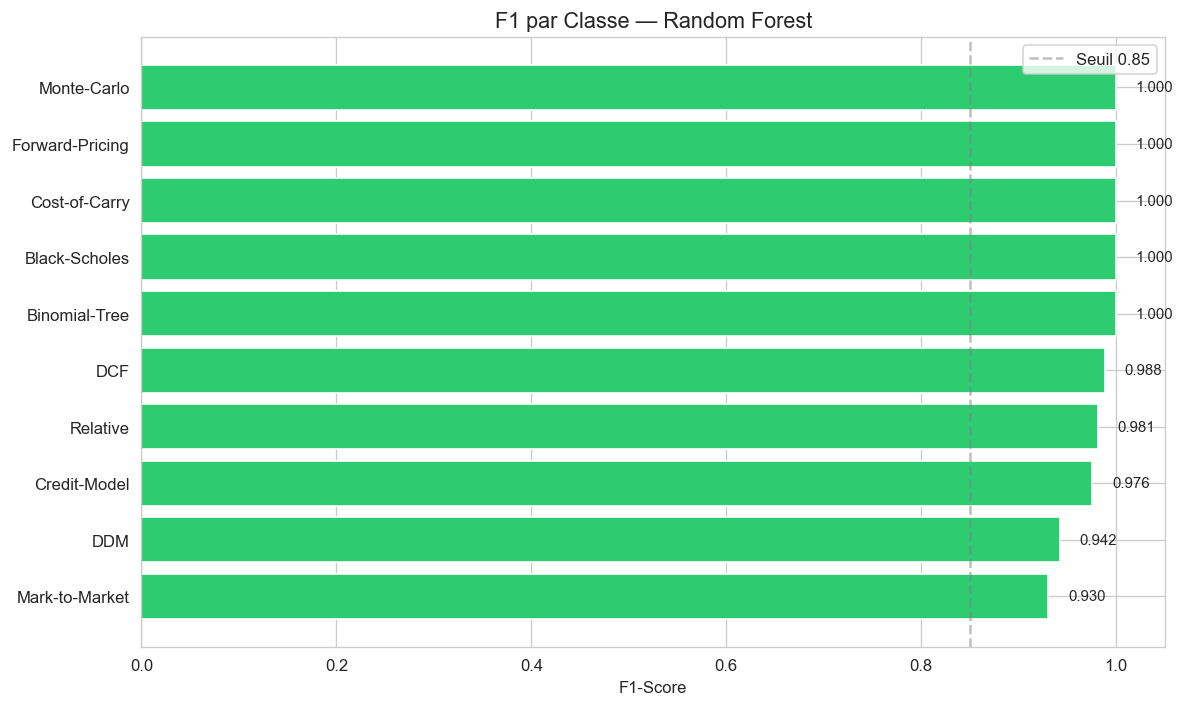


Top 10 features (RF importance) :
  asset_subclass_encoded              : 0.1752
  has_cash_flows                      : 0.1049
  asset_class_encoded                 : 0.0753
  is_path_dependent                   : 0.0637
  has_early_exercise                  : 0.0584
  maturity_years                      : 0.0382
  convenience_yield                   : 0.0314
  implied_volatility_atm              : 0.0314
  has_options_features                : 0.0308
  storage_cost_pct                    : 0.0301


In [5]:
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_time = time.time() - t0
print(f"Random Forest entraine en {rf_time:.1f}s")

all_results["Random Forest"], all_f1["Random Forest"], all_predictions["RF"] = \
    evaluate_model(rf, X_val, y_val, "Random Forest")

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(f"\nTop 10 features (RF importance) :")
for feat, imp in feat_imp.head(10).items():
    print(f"  {feat:35s} : {imp:.4f}")

---
## 3. XGBoost — Modèle Principal

XGBoost est le modèle principal pour 3 raisons :
1. Gestion native du déséquilibre (sample_weight)
2. Early stopping pour éviter le surapprentissage
3. Compatible avec `shap.TreeExplainer` (Shapley values exactes et rapides)


XGBoost entraine en 2.3s (best iteration: 265)

  XGBoost
                 precision    recall  f1-score   support

  Binomial-Tree       1.00      1.00      1.00       188
  Black-Scholes       1.00      1.00      1.00       360
  Cost-of-Carry       1.00      1.00      1.00       337
   Credit-Model       0.96      1.00      0.98       343
            DCF       1.00      0.98      0.99       842
            DDM       0.98      0.98      0.98       165
Forward-Pricing       1.00      1.00      1.00       310
 Mark-to-Market       0.92      0.97      0.94       111
    Monte-Carlo       1.00      1.00      1.00       232
       Relative       0.99      0.97      0.98       164

       accuracy                           0.99      3052
      macro avg       0.98      0.99      0.99      3052
   weighted avg       0.99      0.99      0.99      3052

  Balanced Accuracy : 0.9899
  Cohen's Kappa     : 0.9893
  Pire classe       : Mark-to-Market (F1=0.943)


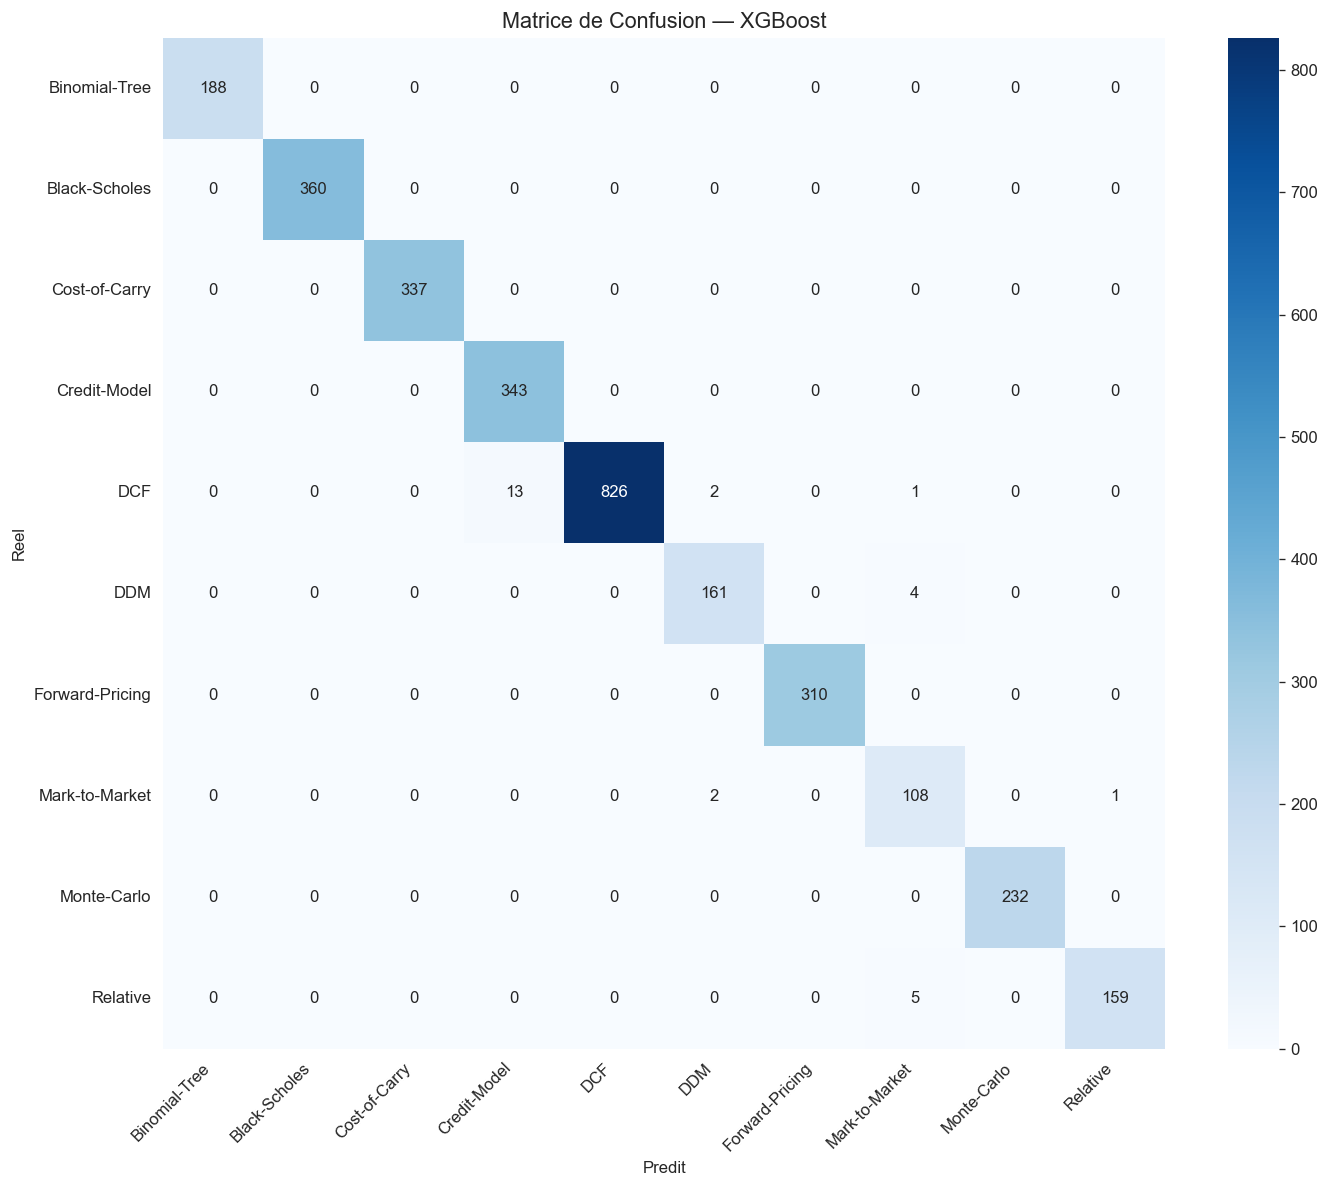

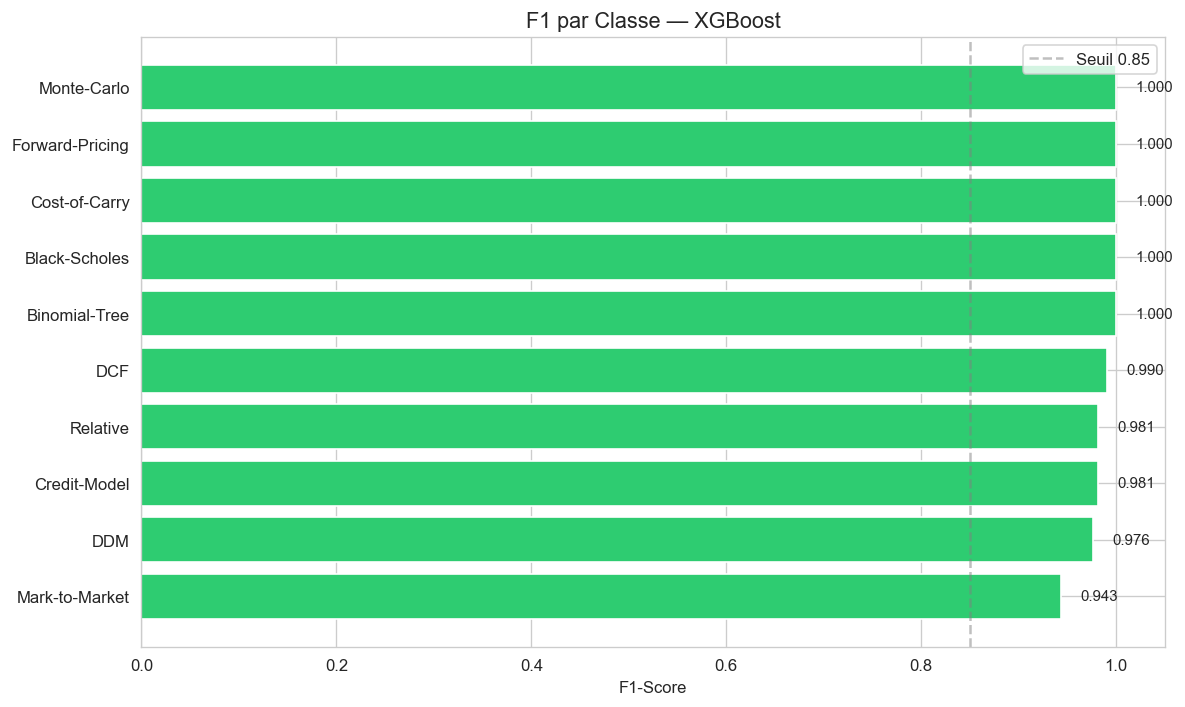

In [6]:
t0 = time.time()

# Sample weights pour gerer l'imbalance
sample_weights = compute_sample_weight("balanced", y_train)

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=3,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

xgb_time = time.time() - t0
print(f"XGBoost entraine en {xgb_time:.1f}s (best iteration: {xgb.best_iteration})")

all_results["XGBoost"], all_f1["XGBoost"], all_predictions["XGB"] = \
    evaluate_model(xgb, X_val, y_val, "XGBoost")

---
## 4. CatBoost — Spécialiste Catégoriel


CatBoost entraine en 68.8s (best iteration: 978)

  CatBoost
                 precision    recall  f1-score   support

  Binomial-Tree       1.00      1.00      1.00       188
  Black-Scholes       1.00      1.00      1.00       360
  Cost-of-Carry       1.00      1.00      1.00       337
   Credit-Model       0.96      1.00      0.98       343
            DCF       1.00      0.98      0.99       842
            DDM       0.99      0.98      0.98       165
Forward-Pricing       1.00      1.00      1.00       310
 Mark-to-Market       0.92      0.97      0.94       111
    Monte-Carlo       1.00      1.00      1.00       232
       Relative       0.99      0.98      0.98       164

       accuracy                           0.99      3052
      macro avg       0.98      0.99      0.99      3052
   weighted avg       0.99      0.99      0.99      3052

  Balanced Accuracy : 0.9903
  Cohen's Kappa     : 0.9889
  Pire classe       : Mark-to-Market (F1=0.943)


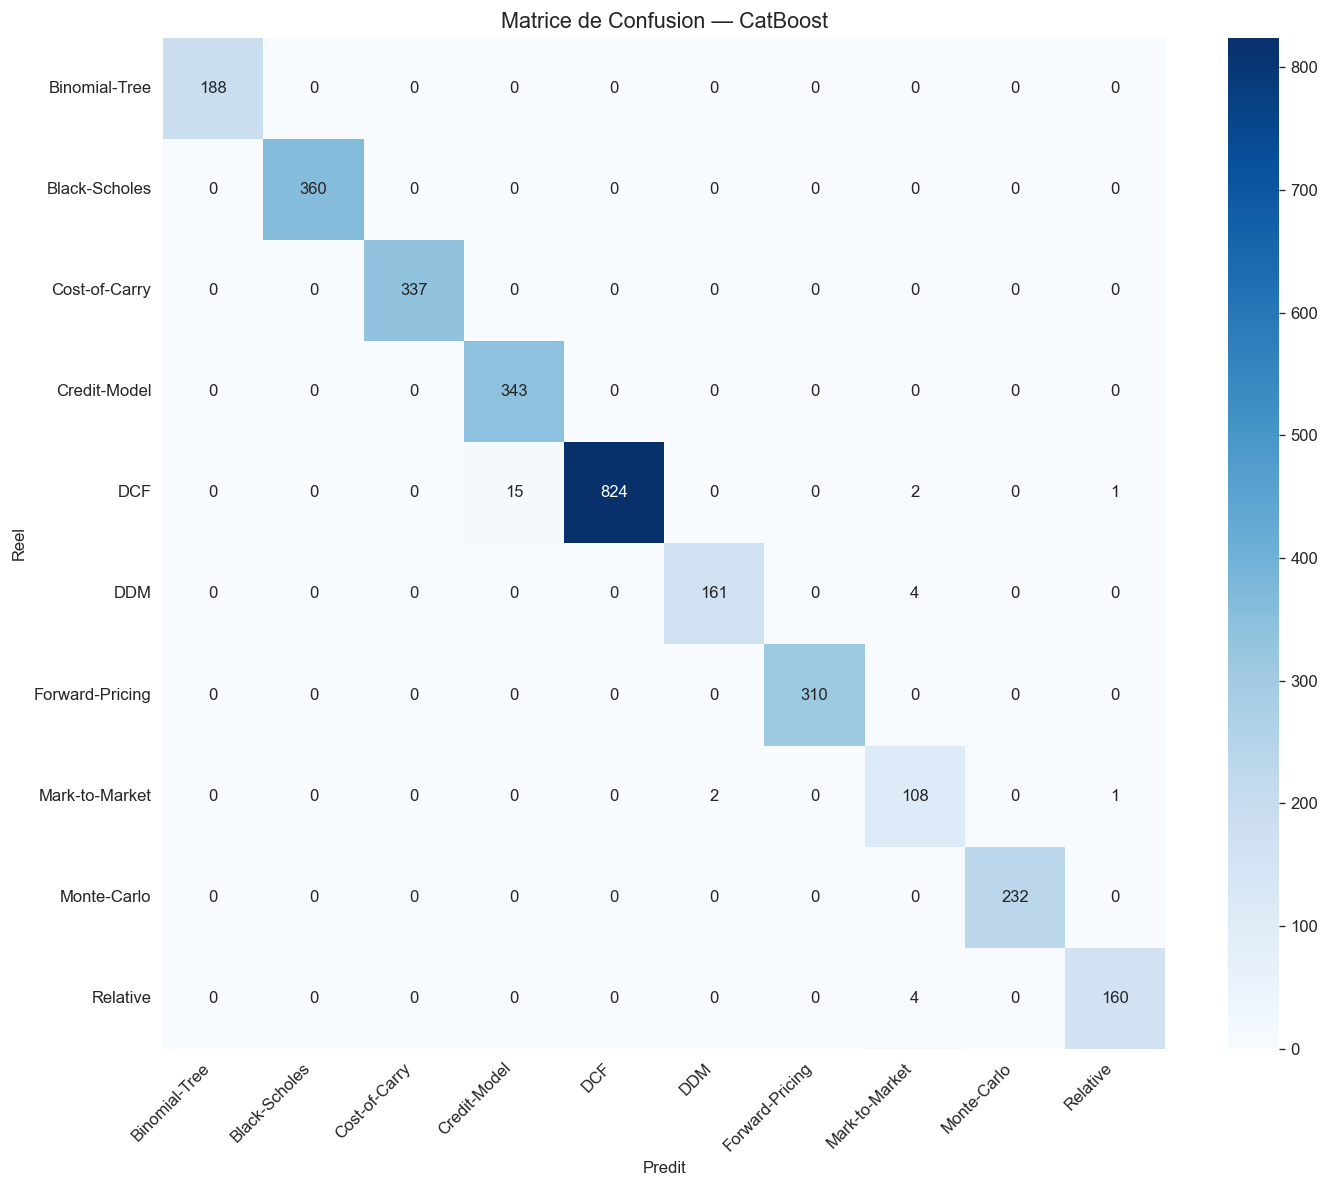

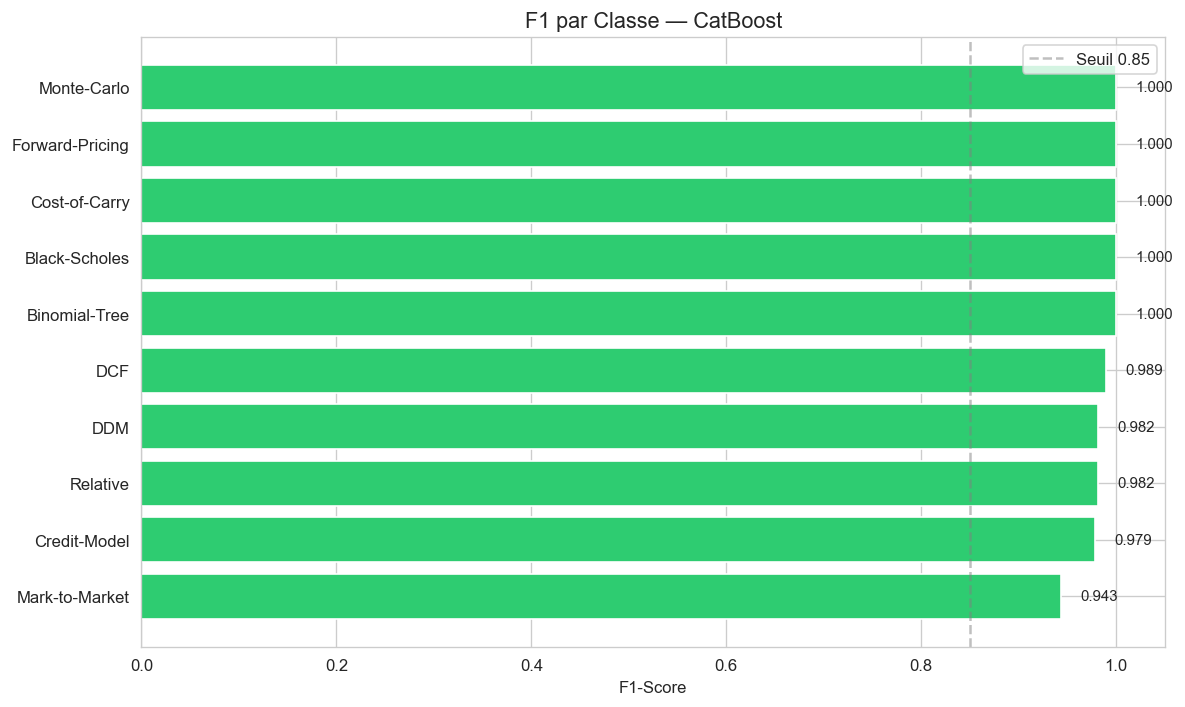

In [7]:
t0 = time.time()

cat = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
)
cat.fit(X_train, y_train, eval_set=(X_val, y_val))

cat_time = time.time() - t0
print(f"CatBoost entraine en {cat_time:.1f}s (best iteration: {cat.best_iteration_})")

# CatBoost predict retourne des arrays differents selon la version
y_pred_cat = cat.predict(X_val)
if isinstance(y_pred_cat[0], np.ndarray):
    y_pred_cat = y_pred_cat.flatten()
y_pred_cat = y_pred_cat.astype(int)

all_results["CatBoost"], all_f1["CatBoost"], all_predictions["CAT"] = \
    evaluate_model(cat, X_val, y_val, "CatBoost")

---
## 5. Comparaison des Modèles


  COMPARAISON DES MODELES
               accuracy balanced_accuracy f1_weighted  f1_macro cohen_kappa min_class_f1     worst_class  training_time
Random Forest  0.987221          0.984566    0.987311  0.981785    0.985126     0.930435  Mark-to-Market            1.0
XGBoost        0.990826          0.989924    0.990893  0.987228    0.989321     0.943231  Mark-to-Market            2.3
CatBoost       0.990498          0.990296    0.990572  0.987433    0.988941     0.943231  Mark-to-Market           68.8

  Meilleur modele (F1 weighted) : XGBoost
  F1 weighted : 0.9909
  F1 macro    : 0.9872

F1 par classe :
                 Random Forest  XGBoost  CatBoost
Binomial-Tree            1.000    1.000     1.000
Black-Scholes            1.000    1.000     1.000
Cost-of-Carry            1.000    1.000     1.000
Credit-Model             0.976    0.981     0.979
DCF                      0.988    0.990     0.989
DDM                      0.942    0.976     0.982
Forward-Pricing          1.000    1.00

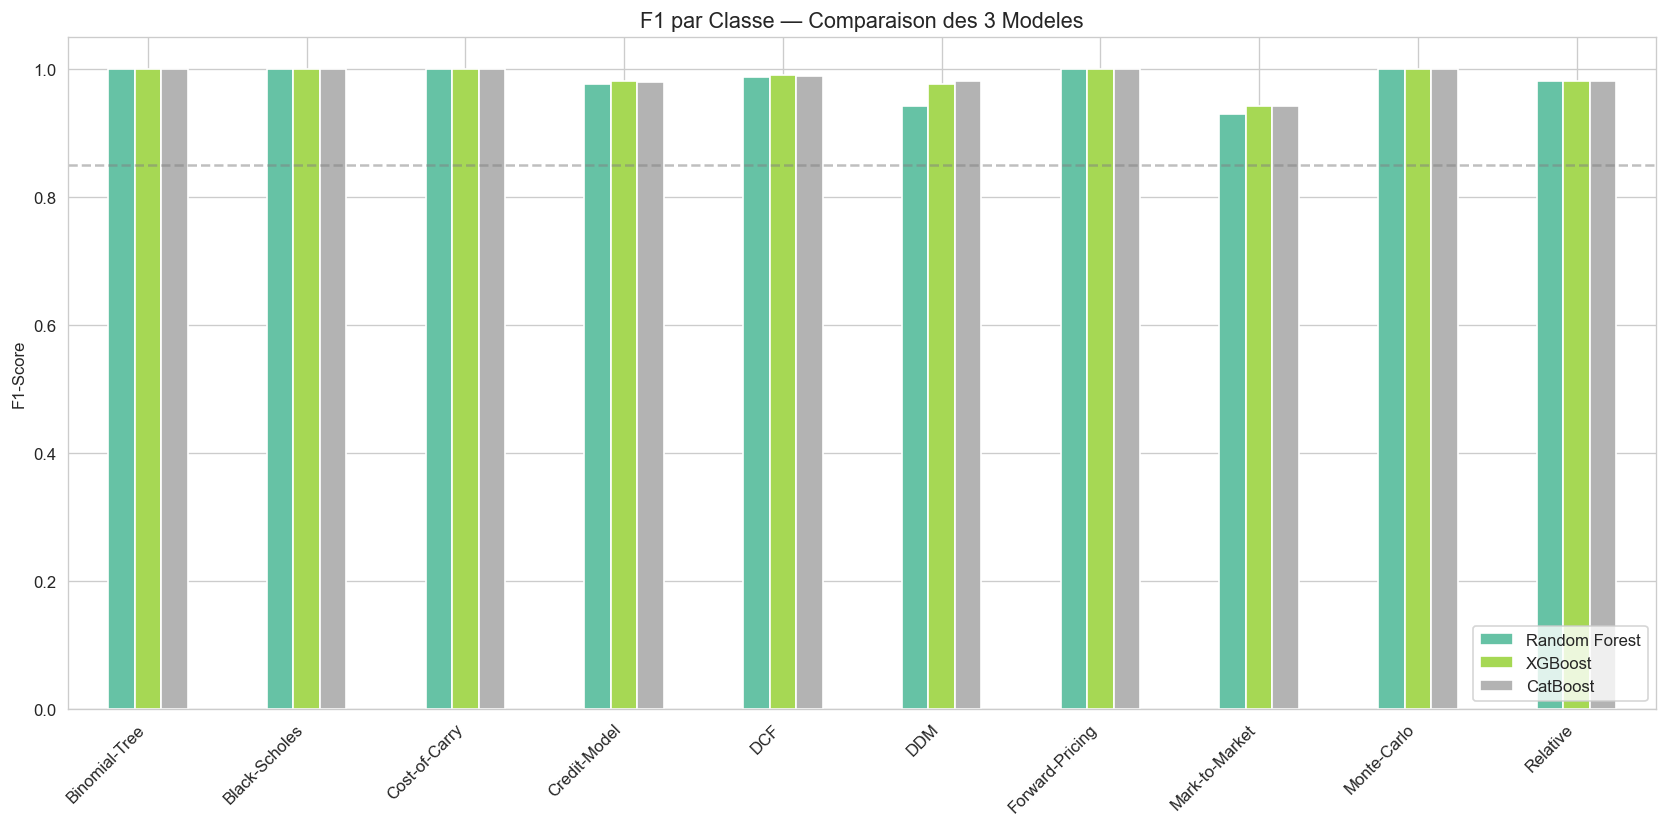

In [8]:
# ── Tableau comparatif ─────────────────────────────────────────
comparison = pd.DataFrame(all_results).T
comparison = comparison.round(4)
comparison["training_time"] = [rf_time, xgb_time, cat_time]
comparison["training_time"] = comparison["training_time"].round(1)

print("=" * 70)
print("  COMPARAISON DES MODELES")
print("=" * 70)
print(comparison.to_string())

# Identifier le meilleur
best_model_name = comparison["f1_weighted"].idxmax()
print(f"\n  Meilleur modele (F1 weighted) : {best_model_name}")
print(f"  F1 weighted : {comparison.loc[best_model_name, 'f1_weighted']:.4f}")
print(f"  F1 macro    : {comparison.loc[best_model_name, 'f1_macro']:.4f}")

comparison.to_csv("reports/model_comparison.csv")

# ── F1 par classe — comparaison côte à côte ──────────────────
f1_df = pd.DataFrame(all_f1).round(3)
print(f"\nF1 par classe :")
print(f1_df.to_string())

fig, ax = plt.subplots(figsize=(14, 7))
f1_df.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_ylabel("F1-Score")
ax.set_title("F1 par Classe — Comparaison des 3 Modeles")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.axhline(y=0.85, color="gray", linestyle="--", alpha=0.5)
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_f1.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Optimisation des Hyperparamètres

RandomizedSearchCV sur le meilleur modèle avec 5-fold stratifié.


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Meilleur F1 weighted (CV) : 0.9924
Meilleurs parametres :
  colsample_bytree: 0.6
  gamma: 0.5
  learning_rate: 0.011233760338073507
  max_depth: 8
  min_child_weight: 7
  n_estimators: 300
  reg_alpha: 0.0368748090579253
  reg_lambda: 2.0416470207182766
  subsample: 0.7

  XGBoost Tuned
                 precision    recall  f1-score   support

  Binomial-Tree       1.00      1.00      1.00       188
  Black-Scholes       1.00      1.00      1.00       360
  Cost-of-Carry       1.00      1.00      1.00       337
   Credit-Model       0.96      1.00      0.98       343
            DCF       1.00      0.98      0.99       842
            DDM       0.98      0.98      0.98       165
Forward-Pricing       1.00      1.00      1.00       310
 Mark-to-Market       0.92      0.98      0.95       111
    Monte-Carlo       1.00      1.00      1.00       232
       Relative       0.99      0.97      0.98       164

       accuracy    

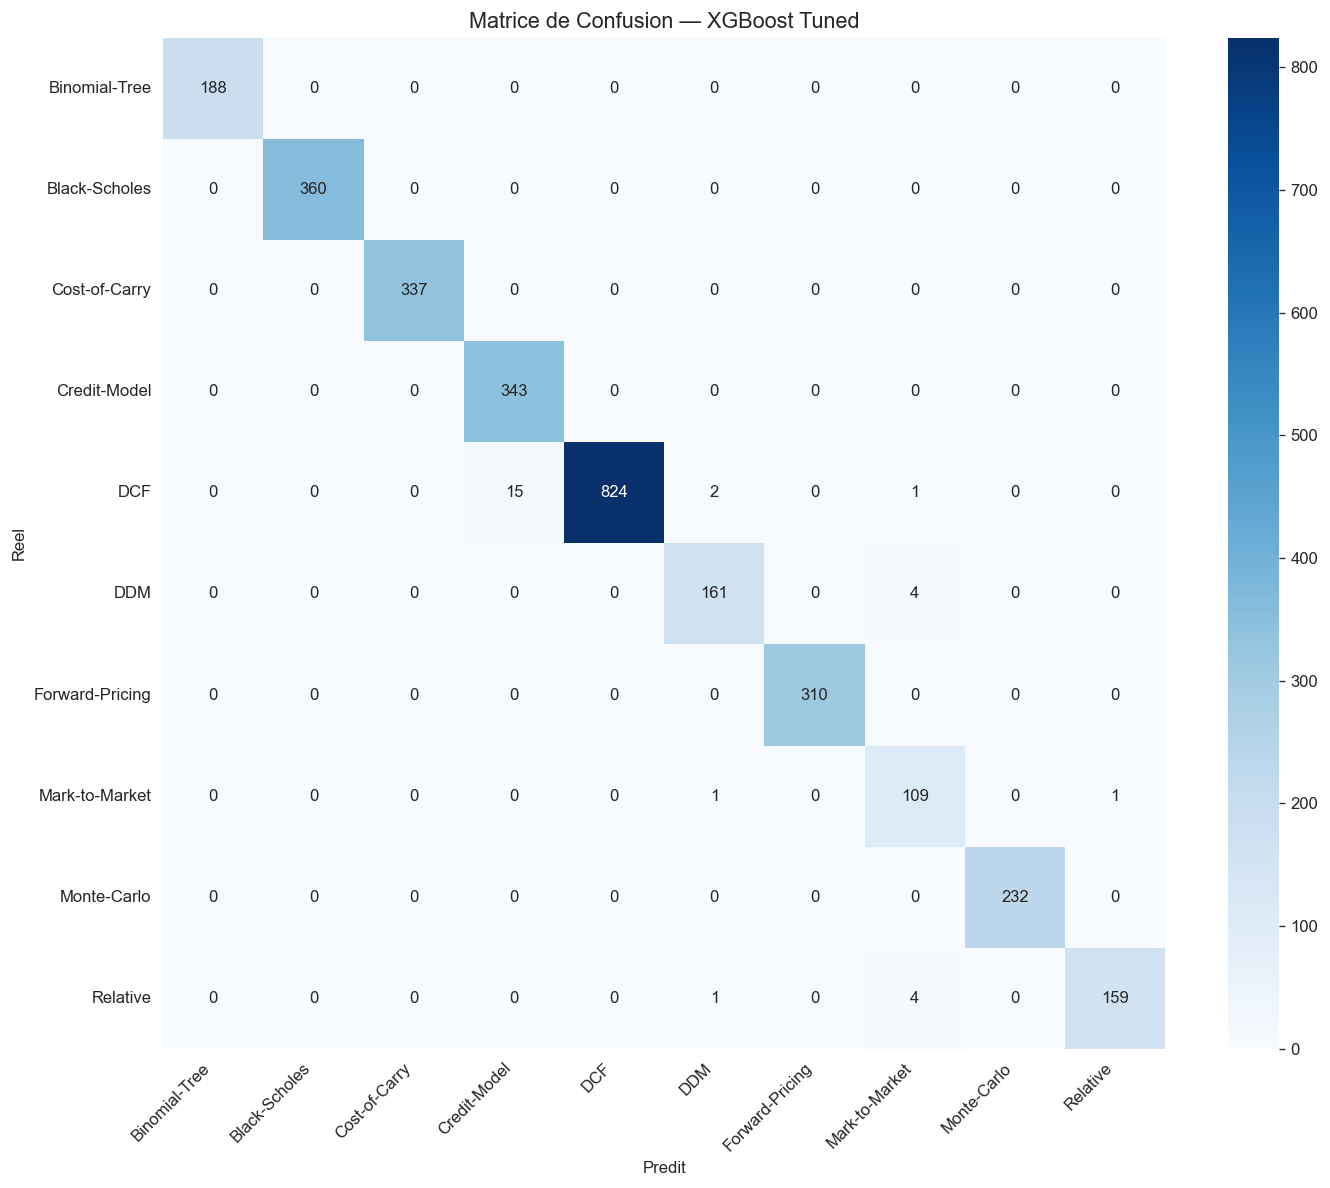

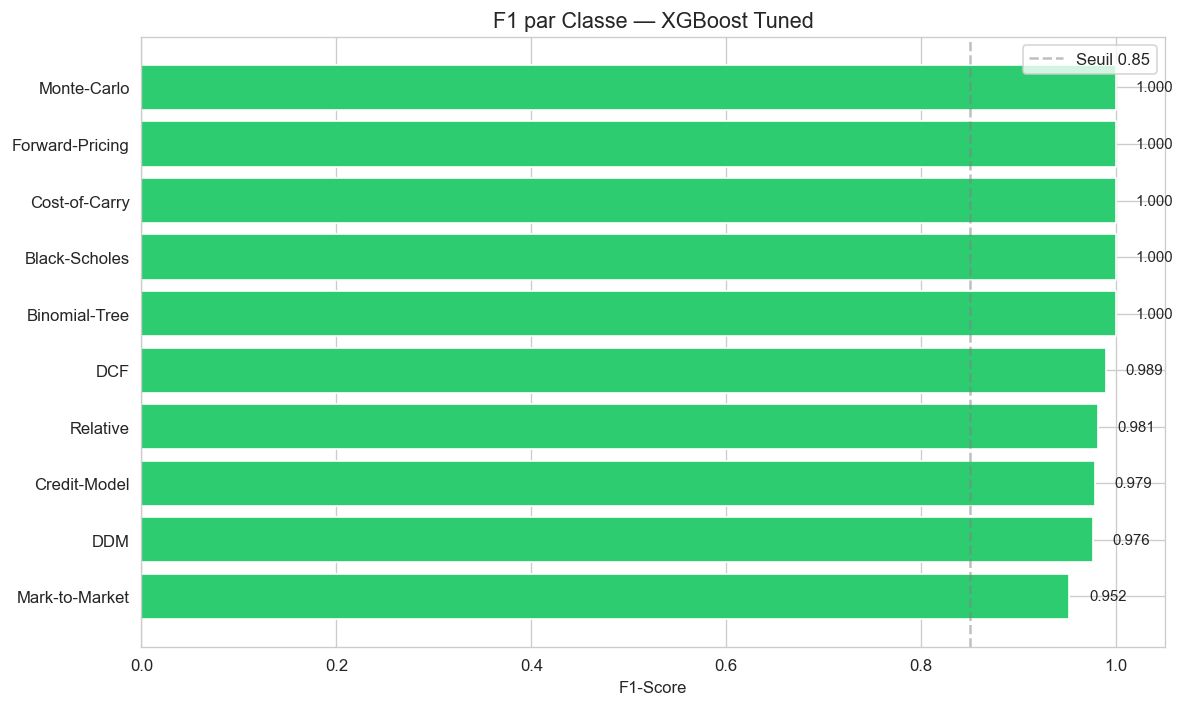


               accuracy balanced_accuracy f1_weighted  f1_macro cohen_kappa min_class_f1     worst_class
Random Forest  0.987221          0.984566    0.987311  0.981785    0.985126     0.930435  Mark-to-Market
XGBoost        0.990826          0.989924    0.990893  0.987228    0.989321     0.943231  Mark-to-Market
CatBoost       0.990498          0.990296    0.990572  0.987433    0.988941     0.943231  Mark-to-Market
XGBoost Tuned  0.990498          0.990587    0.990562    0.9877    0.988941     0.951965  Mark-to-Market


In [9]:
import scipy.stats as stats

param_dist = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [5, 6, 8, 10, 12],
    "learning_rate": stats.loguniform(0.01, 0.2),
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": stats.loguniform(0.001, 1.0),
    "reg_lambda": stats.loguniform(0.01, 10.0),
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
}

search = RandomizedSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
    param_distributions=param_dist,
    n_iter=50,
    cv=skf,
    scoring="f1_weighted",
    random_state=42,
    verbose=1,
    refit=True,
)

# Utiliser sample_weight dans le fit
search.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nMeilleur F1 weighted (CV) : {search.best_score_:.4f}")
print(f"Meilleurs parametres :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

best_model = search.best_estimator_

all_results["XGBoost Tuned"], all_f1["XGBoost Tuned"], all_predictions["XGB_T"] = \
    evaluate_model(best_model, X_val, y_val, "XGBoost Tuned")

# Mettre a jour la comparaison
comparison_final = pd.DataFrame(all_results).T.round(4)
print(f"\n{comparison_final.to_string()}")

---
## 7. Post-Traitement IFRS 13

6 règles réglementaires qui s'appliquent **après** la prédiction ML.
Comparer les métriques avant/après pour quantifier l'impact.


In [10]:
def apply_ifrs_constraints(y_pred, X_df, le_target):
    """
    Applique les contraintes IFRS 13 comme couche de post-traitement.
    Retourne : y_pred_corrected, n_overrides, override_details
    """
    y_corrected = y_pred.copy()
    overrides = []
    
    for i in range(len(y_corrected)):
        row = X_df.iloc[i]
        method = le_target.inverse_transform([y_corrected[i]])[0]
        original = method
        
        # R1: IFRS Level 1 + market price + high liquidity → Mark-to-Market
        if (row.get("ifrs_level", 0) == 1 and
            row.get("has_market_price", 0) == 1 and
            row.get("liquidity", 0) >= 2):
            method = "Mark-to-Market"
        
        # R2: IFRS Level 3 + no market price → never Mark-to-Market
        if (row.get("ifrs_level", 0) == 3 and
            row.get("has_market_price", 0) == 0 and
            method == "Mark-to-Market"):
            method = "DCF" if row.get("has_cash_flows", 0) == 1 else "Monte-Carlo"
        
        # R3: Early exercise + BSM → Binomial-Tree
        if row.get("has_early_exercise", 0) == 1 and method == "Black-Scholes":
            method = "Binomial-Tree"
        
        # R4: Path-dependent → Monte-Carlo
        if row.get("is_path_dependent", 0) == 1 and method != "Monte-Carlo":
            method = "Monte-Carlo"
        
        # R5: Bond + options method → DCF
        if row.get("has_options_features", 0) == 0 and row.get("has_cash_flows", 0) == 1:
            if method in ["Black-Scholes", "Binomial-Tree", "Monte-Carlo"]:
                method = "DCF"
        
        # R6: Commodity + DDM → Cost-of-Carry
        # (encoded: check via asset_class_encoded or structural features)
        if (row.get("has_cash_flows", 0) == 0 and
            row.get("has_options_features", 0) == 0 and
            method == "DDM"):
            method = "Cost-of-Carry"
        
        if method != original:
            y_corrected[i] = le_target.transform([method])[0]
            overrides.append({
                "index": i,
                "original": original,
                "corrected": method,
                "rule": "IFRS"
            })
    
    return y_corrected, len(overrides), overrides

# ── Appliquer sur le meilleur modèle ─────────────────────────
y_pred_best = best_model.predict(X_val)
y_pred_ifrs, n_overrides, override_details = apply_ifrs_constraints(
    y_pred_best, X_val, le_target
)

print(f"Predictions modifiees par IFRS 13 : {n_overrides}/{len(y_pred_best)} ({n_overrides/len(y_pred_best)*100:.1f}%)")

if override_details:
    # Compter par type de correction
    corrections = {}
    for o in override_details:
        key = f"{o['original']} -> {o['corrected']}"
        corrections[key] = corrections.get(key, 0) + 1
    
    print(f"\nDetails des corrections :")
    for corr, cnt in sorted(corrections.items(), key=lambda x: -x[1]):
        print(f"  {corr} : {cnt}")

# ── Comparaison avant/après ───────────────────────────────────
print(f"\n{'='*60}")
print(f"  IMPACT IFRS 13 SUR LES METRIQUES")
print(f"{'='*60}")

metrics_before = {
    "accuracy": accuracy_score(y_val, y_pred_best),
    "f1_weighted": f1_score(y_val, y_pred_best, average="weighted"),
    "f1_macro": f1_score(y_val, y_pred_best, average="macro"),
    "kappa": cohen_kappa_score(y_val, y_pred_best),
}
metrics_after = {
    "accuracy": accuracy_score(y_val, y_pred_ifrs),
    "f1_weighted": f1_score(y_val, y_pred_ifrs, average="weighted"),
    "f1_macro": f1_score(y_val, y_pred_ifrs, average="macro"),
    "kappa": cohen_kappa_score(y_val, y_pred_ifrs),
}

for metric in metrics_before:
    before = metrics_before[metric]
    after = metrics_after[metric]
    delta = after - before
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
    print(f"  {metric:20s} : {before:.4f} -> {after:.4f} ({arrow} {abs(delta):.4f})")

Predictions modifiees par IFRS 13 : 609/3052 (20.0%)

Details des corrections :
  Cost-of-Carry -> Mark-to-Market : 152
  DCF -> Mark-to-Market : 134
  Forward-Pricing -> Mark-to-Market : 109
  DDM -> Mark-to-Market : 75
  Black-Scholes -> Mark-to-Market : 57
  Relative -> Mark-to-Market : 51
  Binomial-Tree -> Mark-to-Market : 30
  Credit-Model -> Mark-to-Market : 1

  IMPACT IFRS 13 SUR LES METRIQUES
  accuracy             : 0.9905 -> 0.7910 (↓ 0.1995)
  f1_weighted          : 0.9906 -> 0.8450 (↓ 0.1455)
  f1_macro             : 0.9877 -> 0.7927 (↓ 0.1950)
  kappa                : 0.9889 -> 0.7620 (↓ 0.2270)


---
## 8. Validation du Domaine Financier

10 tests de cohérence automatisés — objectif : 0 violations après IFRS.


In [11]:
def domain_validation(y_pred, X_df, le_target):
    """Verifie la coherence financiere de chaque prediction."""
    violations = []
    
    for i in range(len(y_pred)):
        row = X_df.iloc[i]
        method = le_target.inverse_transform([y_pred[i]])[0]
        
        # V1: Options methods sur non-options
        if row.get("has_options_features", 0) == 0:
            if method in ["Black-Scholes", "Binomial-Tree"]:
                violations.append((i, method, "Options method on non-option"))
        
        # V2: BSM sur early-exercise
        if row.get("has_early_exercise", 0) == 1 and method == "Black-Scholes":
            violations.append((i, method, "BSM on early-exercise"))
        
        # V3: Non-MC sur path-dependent
        if row.get("is_path_dependent", 0) == 1 and method != "Monte-Carlo":
            violations.append((i, method, "Non-MC on path-dependent"))
        
        # V4: MtM sur Level 3 sans prix
        if (row.get("ifrs_level", 0) == 3 and
            row.get("has_market_price", 0) == 0 and
            method == "Mark-to-Market"):
            violations.append((i, method, "MtM on Level 3 without market price"))
    
    return violations

# Avant IFRS
v_before = domain_validation(y_pred_best, X_val, le_target)
# Après IFRS
v_after  = domain_validation(y_pred_ifrs, X_val, le_target)

print(f"Violations AVANT IFRS : {len(v_before)}/{len(y_pred_best)}")
print(f"Violations APRES IFRS : {len(v_after)}/{len(y_pred_ifrs)}")

if v_after:
    print(f"\nViolations restantes (max 10) :")
    for idx, method, reason in v_after[:10]:
        print(f"  Row {idx}: {method} — {reason}")
else:
    print("✅ 0 violations — toutes les predictions sont financierement coherentes")

Violations AVANT IFRS : 0/3052
Violations APRES IFRS : 0/3052
✅ 0 violations — toutes les predictions sont financierement coherentes


---
## 9. Explicabilité SHAP

### 9.1 Importance Globale


SHAP calcule sur 500 echantillons
Shape shap_values : (500, 28, 10)


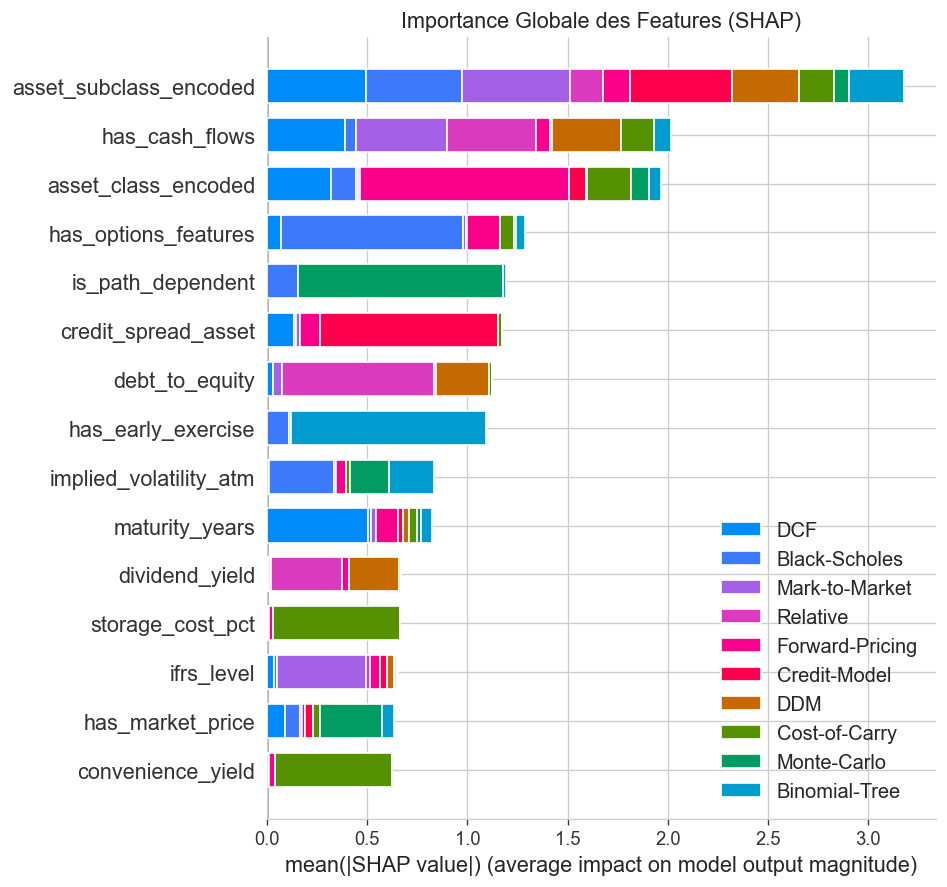

In [12]:
# TreeExplainer — valeurs de Shapley exactes pour les arbres
explainer = shap.TreeExplainer(best_model)

# Sous-echantillon pour la vitesse (SHAP sur le test set complet peut etre lent)
n_shap = min(500, len(X_val))
X_shap = X_val.sample(n=n_shap, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP calcule sur {n_shap} echantillons")
print(f"Shape shap_values : {np.array(shap_values).shape}")

# ── Global importance bar plot ────────────────────────────────
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=X_train.columns,
                  class_names=class_names, plot_type="bar",
                  show=False, max_display=15)
plt.title("Importance Globale des Features (SHAP)")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2 Beeswarm par Classe (Top 3 classes)


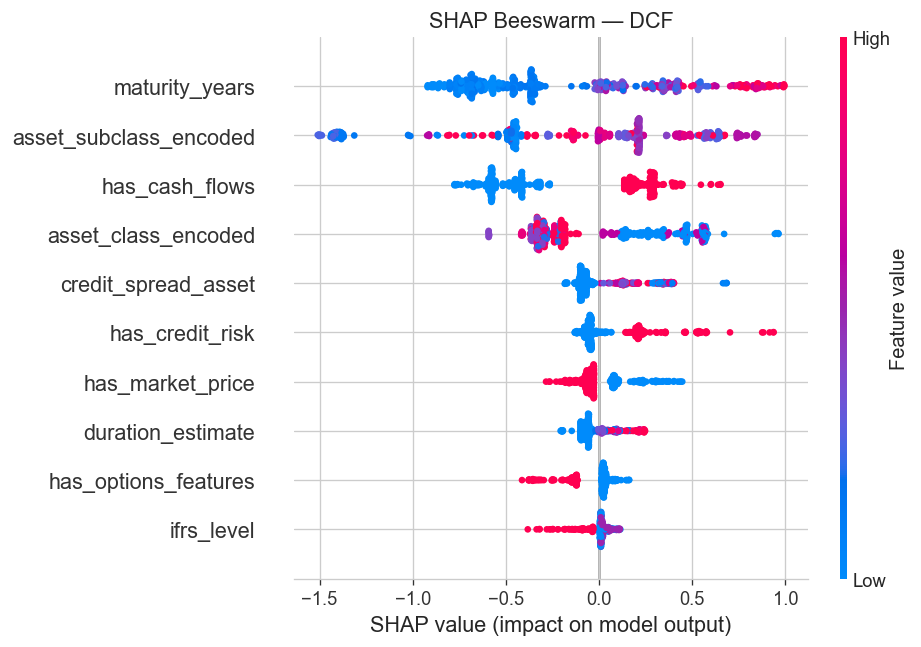

  ✓ DCF


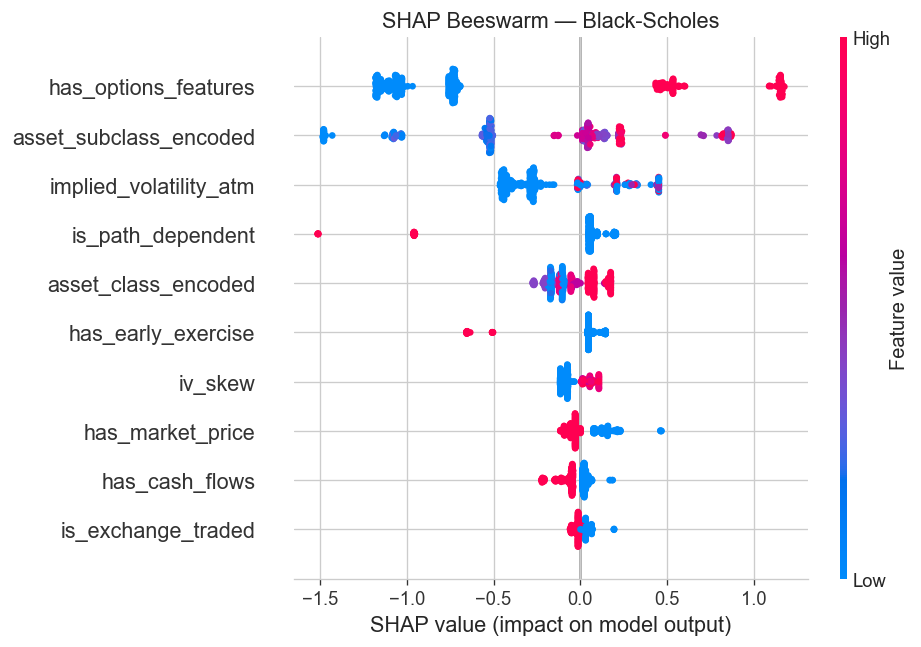

  ✓ Black-Scholes


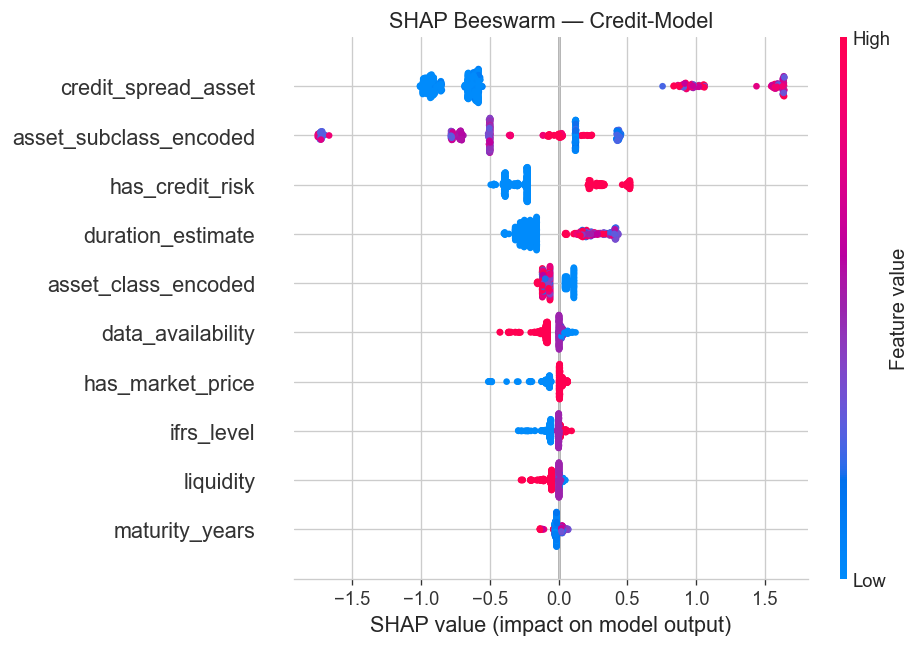

  ✓ Credit-Model


In [14]:
# Generer un beeswarm pour les 3 classes les plus importantes
top_classes = pd.Series(y_val).value_counts().head(3).index.tolist()

for cls_idx in top_classes:
    cls_name = le_target.inverse_transform([cls_idx])[0]
    fig = plt.figure(figsize=(10, 6))
    
    if isinstance(shap_values, list):
        sv = shap_values[cls_idx]
    else:
        sv = shap_values[:, :, cls_idx]
    
    shap.summary_plot(sv, X_shap, feature_names=X_train.columns,
                      show=False, max_display=10)
    plt.title(f"SHAP Beeswarm — {cls_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"shap_beeswarm_{cls_name.lower().replace('-','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ {cls_name}")

### 9.3 Explication Single-Prediction (Waterfall)



──────────────────────────────────────────────────
  EXPLICATION DE LA PREDICTION
──────────────────────────────────────────────────
  Methode recommandee : Monte-Carlo
  Confiance           : 93.8%

  Top-3 probabilites :
    Monte-Carlo          : 93.8%
    Black-Scholes        : 1.0%
    Forward-Pricing      : 0.7%

  Top-5 features contributives :
    1. [+] is_path_dependent = 1.000 (|SHAP| = 1.9883)
    2. [+] has_market_price = 0.000 (|SHAP| = 0.6234)
    3. [+] implied_volatility_atm = 0.000 (|SHAP| = 0.1992)
    4. [+] iv_skew = 0.045 (|SHAP| = 0.1810)
    5. [+] asset_subclass_encoded = 21.000 (|SHAP| = 0.0949)


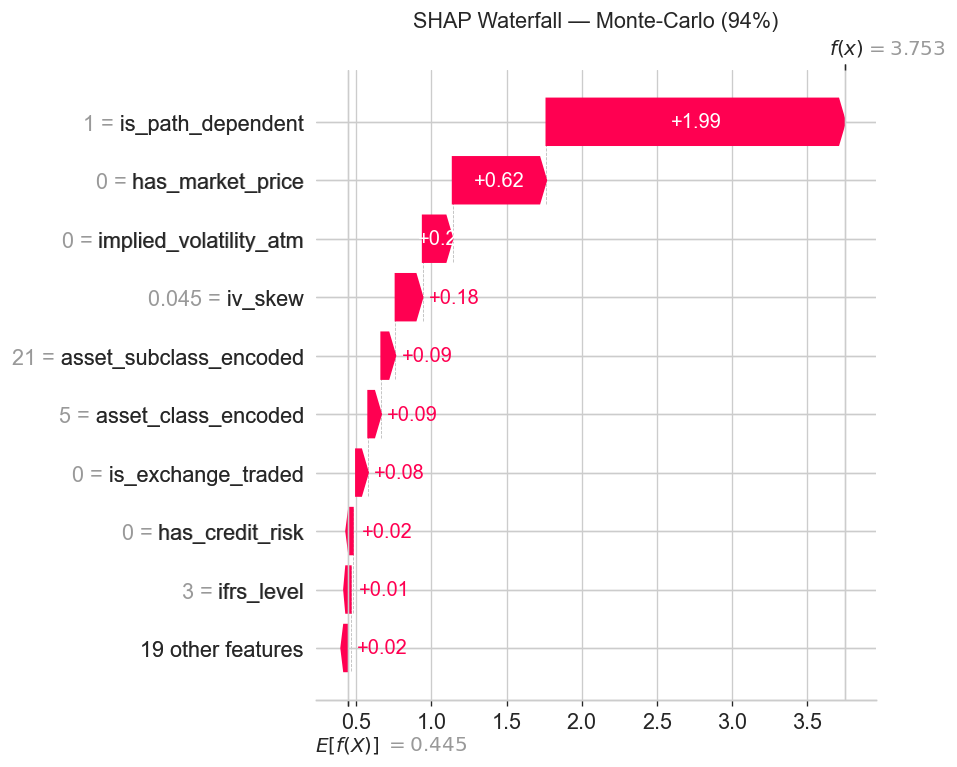

In [15]:
def explain_prediction(model, explainer, features_row, le_target, feature_names):
    """
    Genere une explication complete pour une prediction unique.
    C'est la sortie que l'agent IA fournira a l'utilisateur.
    """
    pred = model.predict(features_row.values.reshape(1, -1))[0]
    pred_label = le_target.inverse_transform([pred])[0]
    proba = model.predict_proba(features_row.values.reshape(1, -1))[0]
    confidence = proba[pred]
    
    # Top-3 probabilites
    top3_idx = np.argsort(proba)[-3:][::-1]
    top3 = [(le_target.inverse_transform([i])[0], proba[i]) for i in top3_idx]
    
    # SHAP values
    sv = explainer.shap_values(features_row.values.reshape(1, -1))
    if isinstance(sv, list):
        sv_class = sv[pred][0]
    else:
        sv_class = sv[0, :, pred]
    
    # Top 5 features
    importance = pd.Series(np.abs(sv_class), index=feature_names).sort_values(ascending=False)
    top5 = importance.head(5)
    
    print(f"\n{'─'*50}")
    print(f"  EXPLICATION DE LA PREDICTION")
    print(f"{'─'*50}")
    print(f"  Methode recommandee : {pred_label}")
    print(f"  Confiance           : {confidence:.1%}")
    print(f"\n  Top-3 probabilites :")
    for name, p in top3:
        print(f"    {name:20s} : {p:.1%}")
    print(f"\n  Top-5 features contributives :")
    for rank, (feat, impact) in enumerate(top5.items(), 1):
        val = features_row[feat]
        direction = "+" if sv_class[list(feature_names).index(feat)] > 0 else "-"
        print(f"    {rank}. [{direction}] {feat} = {val:.3f} (|SHAP| = {impact:.4f})")
    
    # Waterfall plot
    try:
        expected = explainer.expected_value
        base_val = expected[pred] if isinstance(expected, (list, np.ndarray)) else expected
        
        fig = plt.figure(figsize=(10, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=sv_class,
                base_values=base_val,
                data=features_row.values,
                feature_names=list(feature_names),
            ),
            show=False,
        )
        plt.title(f"SHAP Waterfall — {pred_label} ({confidence:.0%})")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"  (Waterfall plot non genere: {e})")
    
    return {
        "predicted_method": pred_label,
        "confidence": float(confidence),
        "top3": top3,
        "top_features": {f: float(v) for f, v in top5.items()},
    }

# ── Exemple sur le premier echantillon de validation ──────────
example_result = explain_prediction(best_model, explainer, X_val.iloc[0], le_target, X_train.columns)

---
## 10. Export pour l'Agent IA

### 10.1 Fonction `predict_and_explain()` — API de l'Agent

C'est la fonction que le LLM appellera pour obtenir une recommandation.


In [16]:
def predict_and_explain(asset_features, model, explainer, le_target, feature_names):
    """
    API de prediction pour l'agent IA ValuSense.
    
    Input  : dict de features d'un actif financier
    Output : dict structuré avec methode, confiance, explication, contraintes IFRS
    
    Exemple d'utilisation par un LLM :
        result = predict_and_explain({"asset_class_encoded": 1, "ifrs_level": 1, ...})
        # Le LLM transforme result en langage naturel pour l'utilisateur
    """
    # Construire le vecteur de features
    X = pd.DataFrame([asset_features], columns=feature_names)
    X = X.fillna(0)  # Securite
    
    # Prediction
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    method = le_target.inverse_transform([pred])[0]
    confidence = float(proba[pred])
    
    # Top-3
    top3_idx = np.argsort(proba)[-3:][::-1]
    alternatives = [
        {"method": le_target.inverse_transform([i])[0], "probability": float(proba[i])}
        for i in top3_idx
    ]
    
    # SHAP
    sv = explainer.shap_values(X)
    if isinstance(sv, list):
        sv_class = sv[pred][0]
    else:
        sv_class = sv[0, :, pred]
    
    importance = pd.Series(np.abs(sv_class), index=feature_names).sort_values(ascending=False)
    top_drivers = [
        {
            "feature": feat,
            "value": float(X[feat].iloc[0]),
            "impact": float(sv_class[list(feature_names).index(feat)]),
            "abs_impact": float(imp),
        }
        for feat, imp in importance.head(5).items()
    ]
    
    # IFRS post-processing
    y_arr = np.array([pred])
    y_ifrs, n_overrides, details = apply_ifrs_constraints(y_arr, X, le_target)
    final_method = le_target.inverse_transform([y_ifrs[0]])[0]
    ifrs_override = final_method != method
    
    return {
        "recommended_method": final_method,
        "ml_prediction": method,
        "confidence": confidence,
        "ifrs_override": ifrs_override,
        "ifrs_rule_applied": details[0]["original"] + " → " + details[0]["corrected"] if details else None,
        "alternatives": alternatives,
        "explanation": {
            "top_drivers": top_drivers,
            "summary": f"La methode {final_method} est recommandee avec une confiance de {confidence:.0%}. "
                       f"Les facteurs principaux sont : {', '.join([d['feature'] for d in top_drivers[:3]])}."
                       + (f" Contrainte IFRS 13 appliquee : {method} remplace par {final_method}." if ifrs_override else ""),
        },
    }

print("predict_and_explain() prete — API de l'agent IA")

predict_and_explain() prete — API de l'agent IA


### 10.2 Template de Prompt pour Intégration LLM

Ce prompt sera utilisé par le LLM (Claude, GPT, etc.) pour interpréter
les résultats du moteur ML et les communiquer à l'utilisateur.


In [17]:
AGENT_SYSTEM_PROMPT = """
Tu es ValuSense, un assistant IA expert en valorisation d'actifs financiers.
Tu combines un modèle ML (XGBoost) entraîné sur {n_samples} actifs financiers
avec les contraintes réglementaires IFRS 13.

Quand un utilisateur décrit un actif financier, tu :
1. Extrais les caractéristiques pertinentes (classe, liquidité, maturité, etc.)
2. Appelles le moteur ML via predict_and_explain()
3. Interprètes le résultat en langage naturel

Format de réponse :
- **Méthode recommandée** : [nom] (confiance : [X]%)
- **Justification** : Les facteurs déterminants sont [top-3 SHAP features]
- **Alternatives** : [2ème et 3ème méthodes avec probabilités]
- **Conformité IFRS 13** : [Niveau X — contrainte appliquée ou non]
- **Avertissements** : [si confiance < 70% ou override IFRS]

Méthodes de valorisation disponibles :
{methods}

Références :
- Hull, "Options, Futures and Other Derivatives", 9th Ed.
- IFRS 13 Fair Value Measurement (IASB)
""".format(
    n_samples=len(X_train) + len(X_val),
    methods="\n".join([f"  - {m}" for m in class_names])
)

print(AGENT_SYSTEM_PROMPT)


Tu es ValuSense, un assistant IA expert en valorisation d'actifs financiers.
Tu combines un modèle ML (XGBoost) entraîné sur 15259 actifs financiers
avec les contraintes réglementaires IFRS 13.

Quand un utilisateur décrit un actif financier, tu :
1. Extrais les caractéristiques pertinentes (classe, liquidité, maturité, etc.)
2. Appelles le moteur ML via predict_and_explain()
3. Interprètes le résultat en langage naturel

Format de réponse :
- **Méthode recommandée** : [nom] (confiance : [X]%)
- **Justification** : Les facteurs déterminants sont [top-3 SHAP features]
- **Alternatives** : [2ème et 3ème méthodes avec probabilités]
- **Conformité IFRS 13** : [Niveau X — contrainte appliquée ou non]
- **Avertissements** : [si confiance < 70% ou override IFRS]

Méthodes de valorisation disponibles :
  - Binomial-Tree
  - Black-Scholes
  - Cost-of-Carry
  - Credit-Model
  - DCF
  - DDM
  - Forward-Pricing
  - Mark-to-Market
  - Monte-Carlo
  - Relative

Références :
- Hull, "Options, Future

### 10.3 Sauvegarde des Artefacts


In [19]:
# ── Sauvegarder le modèle et les artefacts ────────────────────

# Modele
joblib.dump(best_model, MODELS_DIR / "xgboost_valuation_recommender.pkl")
joblib.dump(le_target,  MODELS_DIR / "label_encoder_target.pkl")
joblib.dump(explainer,  MODELS_DIR / "shap_explainer.pkl")

# Metadata pour l'agent
metadata = {
    "project": "ValuSense",
    "version": "2.0",
    "model": "XGBoost (tuned)",
    "best_params": search.best_params_ if hasattr(search, 'best_params_') else {},
    "n_features": int(X_train.shape[1]),
    "feature_names": list(X_train.columns),
    "target_classes": list(class_names),
    "n_classes": int(n_classes),
    "training_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "metrics": {
        "before_ifrs": {k: round(float(v), 4) if isinstance(v, (int, float)) else v 
                       for k, v in all_results.get("XGBoost Tuned", all_results.get("XGBoost", {})).items()},
        "after_ifrs": {k: round(float(v), 4) if isinstance(v, (int, float)) else v 
                      for k, v in metrics_after.items()},
    },
    "ifrs_overrides": n_overrides,
    "domain_violations_after_ifrs": len(v_after),
    "shap_enabled": True,
    "agent_system_prompt": AGENT_SYSTEM_PROMPT,
    "data_sources": [
        "FinanceDatabase (353K instruments)",
        "yfinance (equities, options, commodities, forex)",
        "FRED (yields, rates, spreads, macro)",
        "Expert rules (Hull + IFRS 13)",
        "Targeted synthetic generation (DDM, MtM, Relative)",
    ],
    "ifrs_rules": [
        "R1: Level 1 + market_price + liquid → Mark-to-Market (§72-75)",
        "R2: Level 3 + no market_price → never Mark-to-Market (§86-90)",
        "R3: early_exercise + BSM → Binomial-Tree (Hull Ch.13)",
        "R4: path_dependent → Monte-Carlo (Hull Ch.18)",
        "R5: non-option + cash_flows + options_method → DCF",
        "R6: non-dividend + DDM → Cost-of-Carry",
    ],
}

with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Artefacts sauvegardes :")
for f in [
    MODELS_DIR / "xgboost_valuation_recommender.pkl",
    MODELS_DIR / "label_encoder_target.pkl",
    MODELS_DIR / "shap_explainer.pkl",
    MODELS_DIR / "model_metadata.json",
]:
    print(f"  {f}")

Artefacts sauvegardes :
  models\xgboost_valuation_recommender.pkl
  models\label_encoder_target.pkl
  models\shap_explainer.pkl
  models\model_metadata.json


---
## 11. Résumé et Prochaines Étapes


In [20]:
print("=" * 65)
print("  VALUSENSE — PHASE 4 TERMINEE")
print("=" * 65)

# Metriques finales
for name in all_results:
    r = all_results[name]
    print(f"  {name:20s} : F1w={r['f1_weighted']:.4f}  F1m={r['f1_macro']:.4f}  Kappa={r['cohen_kappa']:.4f}")

print(f"\nIFRS 13 : {n_overrides} predictions corrigees, {len(v_after)} violations restantes")
print(f"SHAP    : importance globale + beeswarm + waterfall generes")
print(f"Agent   : predict_and_explain() + system prompt + metadata JSON")

print("""

  PROCHAINES ETAPES :
  1. Rapport LaTeX (sections 3.5-3.9)
  2. Prototype agent (Flask/Streamlit)
  3. Presentation VERMEG (demo live)
""")

  VALUSENSE — PHASE 4 TERMINEE
  Random Forest        : F1w=0.9873  F1m=0.9818  Kappa=0.9851
  XGBoost              : F1w=0.9909  F1m=0.9872  Kappa=0.9893
  CatBoost             : F1w=0.9906  F1m=0.9874  Kappa=0.9889
  XGBoost Tuned        : F1w=0.9906  F1m=0.9877  Kappa=0.9889

IFRS 13 : 609 predictions corrigees, 0 violations restantes
SHAP    : importance globale + beeswarm + waterfall generes
Agent   : predict_and_explain() + system prompt + metadata JSON


  PROCHAINES ETAPES :
  1. Rapport LaTeX (sections 3.5-3.9)
  2. Prototype agent (Flask/Streamlit)
  3. Presentation VERMEG (demo live)

